In [1]:
from astropy.io import fits
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table

In [2]:
x = np.linspace(-4, 1, 500)
sf_boundary = 0.61/(x-0.05) + 1.30
comp_boundary = 0.61/(x-0.47) + 1.19
liner_boundary = 1.05*x + 0.45

In [3]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

FIT = FitSpectrum()
DP_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=read_ids('dp_samples_ids_test.txt'))
DP_SPECTRA = DP_SPECTRA.stack_data()
DP_SPECTRA = DP_SPECTRA.shift_to_rest_frame()
DP_SPECTRA = FIT.label_emission_lines(DP_SPECTRA, 3)

In [4]:
bpt_samples_df = DP_SPECTRA.df[DP_SPECTRA.df[['OIII', 'Hbeta', 'Halpha', 'NII']].sum(axis=1)==4]
display(bpt_samples_df.head(5))

,TARGETID,RA,DEC,SPECTYPE,LOGM,LOGSFR,z_pipe,z,OII,Hbeta,OIII,Halpha,NII,SII
8,39627739384253125,177.367221,-1.890628,GALAXY,9.603887,0.054528,0.082792,0.082792,True,True,True,True,True,True
13,39627739388446113,177.554279,-1.971866,GALAXY,10.489296,0.985447,0.083630,0.083630,True,True,True,True,True,True
14,39627739388450085,177.708902,-1.988507,GALAXY,10.169886,0.802034,0.174826,0.174826,True,True,True,True,True,True
23,39627739396834832,178.063985,-1.937666,GALAXY,9.580146,0.290835,0.166120,0.166120,True,True,True,True,True,True
28,39627739401028028,178.269181,-1.967783,GALAXY,10.064744,0.713474,0.235751,0.235751,True,True,True,True,True,True


In [5]:
DP_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=bpt_samples_df['TARGETID'].to_list())
DP_SPECTRA = DP_SPECTRA.stack_data()
DP_SPECTRA = DP_SPECTRA.shift_to_rest_frame()
DP_SPECTRA = FIT.label_emission_lines(DP_SPECTRA, 3)

In [6]:
display(DP_SPECTRA.df.head(5))

,TARGETID,RA,DEC,SPECTYPE,LOGM,LOGSFR,z_pipe,z,OII,Hbeta,OIII,Halpha,NII,SII
0,39627739384253125,177.367221,-1.890628,GALAXY,9.603887,0.054528,0.082792,0.082792,True,True,True,True,True,True
1,39627739388446113,177.554279,-1.971866,GALAXY,10.489296,0.985447,0.083630,0.083630,True,True,True,True,True,True
2,39627739388450085,177.708902,-1.988507,GALAXY,10.169886,0.802034,0.174826,0.174826,True,True,True,True,True,True
3,39627739396834832,178.063985,-1.937666,GALAXY,9.580146,0.290835,0.166120,0.166120,True,True,True,True,True,True
4,39627739401028028,178.269181,-1.967783,GALAXY,10.064744,0.713474,0.235751,0.235751,True,True,True,True,True,True


In [7]:
dp_samples = fits.open('sample_catalog.fits')
bpt_samples_df_fits = Table(dp_samples[1].data).to_pandas().iloc[bpt_samples_df.index]
model_1comp = dp_samples[2].data[bpt_samples_df.index]
model_2comp_l = dp_samples[3].data[bpt_samples_df.index]
model_2comp_r = dp_samples[4].data[bpt_samples_df.index]

FileNotFoundError: [Errno 2] No such file or directory: 'sample_catalog.fits'

In [ ]:
bpt_samples_df_fits.head(5)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,OII3726_dp,OII3729_dp,Hbeta_dp,OIII4959_dp,OIII5007_dp,NII6548_dp,Halpha_dp,NII6583_dp,SII6716_dp,SII6731_dp
9,39627739459752218,181.914886,-1.896473,0.156940,10.010163,0.784921,59.791534,-47.830563,40.169281,46.782898,...,False,True,False,False,False,False,True,False,False,False
15,39627739531056699,186.249435,-1.942276,0.234485,10.009497,0.766355,34.894554,-78.828629,74.387383,23.142733,...,False,False,False,False,False,False,True,False,False,False
18,39627739589772188,189.547775,-1.957934,0.134977,9.798332,-0.000763,76.836151,-24.662128,22.628342,30.973047,...,False,False,False,False,False,False,True,False,False,False
20,39627739610744640,190.838745,-1.937182,0.107054,9.740801,0.384556,43.208447,-81.997612,33.559673,35.382595,...,True,True,True,False,True,True,True,True,True,True
22,39627739631716433,192.110092,-1.950457,0.179482,9.758053,1.366627,77.430107,-43.874977,42.378117,45.172279,...,True,True,True,False,True,True,True,True,True,True


In [ ]:
print(len(bpt_samples_df_fits))

443


In [ ]:
bpt_samples_df_fits[bpt_samples_df_fits[['OIII5007_dp', 'Hbeta_dp', 'Halpha_dp', 'NII6583_dp']].sum(axis=1)==4].head()

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,OII3726_dp,OII3729_dp,Hbeta_dp,OIII4959_dp,OIII5007_dp,NII6548_dp,Halpha_dp,NII6583_dp,SII6716_dp,SII6731_dp
20,39627739610744640,190.838745,-1.937182,0.107054,9.740801,0.384556,43.208447,-81.997612,33.559673,35.382595,...,True,True,True,False,True,True,True,True,True,True
22,39627739631716433,192.110092,-1.950457,0.179482,9.758053,1.366627,77.430107,-43.874977,42.378117,45.172279,...,True,True,True,False,True,True,True,True,True,True
40,39627739812070633,202.799088,-1.972521,0.148798,9.975606,0.770862,65.142357,-37.549274,37.407803,45.409775,...,True,True,True,False,True,False,True,True,True,True
58,39627739963069440,211.998993,-1.911888,0.113802,9.891243,-1.605185,76.062897,-92.534225,34.480473,50.430012,...,True,True,True,True,True,False,True,True,True,True
66,39627740055341841,217.365540,-1.977408,0.079984,9.311695,-0.465883,33.019508,-47.492672,15.819841,41.071358,...,True,True,True,False,True,False,True,True,True,True


In [ ]:
test_idx = np.random.randint(0, len(bpt_samples_df_fits))
test_1comp = model_1comp[test_idx]
test_2comp_l = model_2comp_l[test_idx]
test_2comp_r = model_2comp_r[test_idx]
test_2comp = test_2comp_l + test_2comp_r
lam, flux, ivar = DP_SPECTRA.data_stack[test_idx, 0, :], DP_SPECTRA.data_stack[test_idx, 1, :], DP_SPECTRA.data_stack[test_idx, 2, :]
emission = DP_SPECTRA.data_stack[test_idx, 5, :]
sigma = 1/np.sqrt(np.abs(ivar))


/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_17073/3746070183.py:8: RuntimeWarning: divide by zero encountered in divide
  sigma = 1/np.sqrt(np.abs(ivar))


In [ ]:
print(bpt_samples_df_fits['TARGETID'].iloc[test_idx])

39627752118161734


In [ ]:
fluxes_r = []
fluxes_l = []
for i, lam0 in enumerate([Hbeta_rest[0], OIII_rest[1], Halpha_rest[0], NII_rest[1]]):
    offset_r = bpt_samples_df_fits['dv_r'].iloc[test_idx]/c * lam0
    offset_l = bpt_samples_df_fits['dv_l'].iloc[test_idx]/c * lam0
    flux_r = np.max(test_2comp_r[(lam>lam0+offset_r-1)&(lam<lam0+offset_r+1)])
    flux_l = np.max(test_2comp_l[(lam>lam0+offset_l-1)&(lam<lam0+offset_l+1)])
    fluxes_r.append(flux_r)
    fluxes_l.append(flux_l)

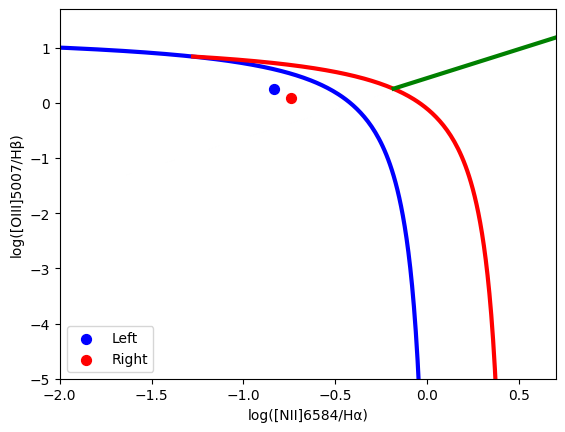

In [ ]:
oiii_hbeta_ratio_r = np.log10(fluxes_r[1]/fluxes_r[0])
oiii_hbeta_ratio_l = np.log10(fluxes_l[1]/fluxes_l[0])

nii_halpha_ratio_r = np.log10(fluxes_r[3]/fluxes_r[2])
nii_halpha_ratio_l = np.log10(fluxes_l[3]/fluxes_l[2])


plt.scatter(nii_halpha_ratio_l, oiii_hbeta_ratio_l, color='blue', label='Left', s=50)
plt.scatter(nii_halpha_ratio_r, oiii_hbeta_ratio_r, color='red', label='Right', s=50)
plt.plot(x[(x<0.05)|((sf_boundary<comp_boundary)&(sf_boundary<liner_boundary))], sf_boundary[(x<0.05)|((sf_boundary<comp_boundary)&(sf_boundary<liner_boundary))], color='blue', linewidth=3)
plt.plot(x[(x<0.47)&(comp_boundary>sf_boundary)|(comp_boundary<liner_boundary)], comp_boundary[(x<0.47)&(comp_boundary>sf_boundary)|(comp_boundary<liner_boundary)], color='red', linewidth=3)
plt.plot(x[(x>0)|(liner_boundary>comp_boundary)], liner_boundary[(x>0)|(liner_boundary>comp_boundary)], color='green', linewidth=3)
plt.xlabel('log([NII]6584/Hα)')
plt.ylabel('log([OIII]5007/Hβ)')
plt.xlim(-2, .7)
plt.ylim(-5, 1.7)
plt.legend()
plt.show()